In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


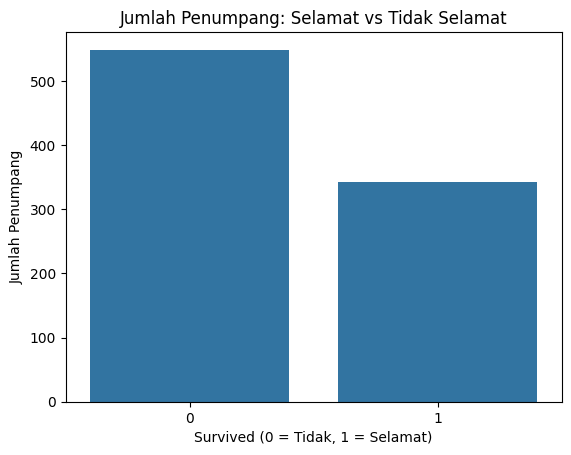

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah yang selamat vs tidak
# value_counts() menghitung frekuensi tiap nilai
survival_counts = df['Survived'].value_counts()

# Buat bar chart
sns.countplot(x='Survived', data=df)

# Beri label agar grafik mudah dibaca
plt.title('Jumlah Penumpang: Selamat vs Tidak Selamat')
plt.xlabel('Survived (0 = Tidak, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')

plt.show()

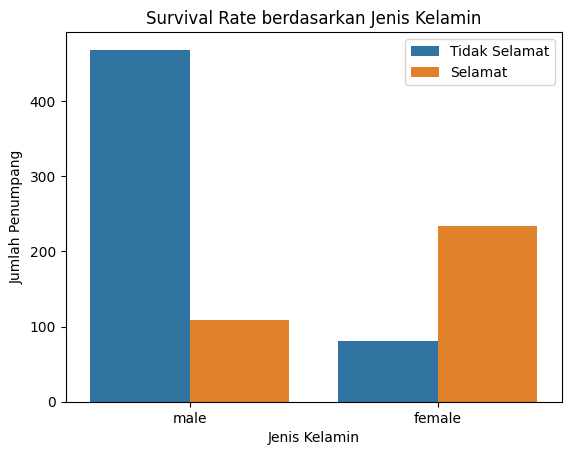

In [5]:
# Bandingkan survival rate antara pria dan wanita
# hue='Survived' memisahkan bar berdasarkan status selamat
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival Rate berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Penumpang')
plt.legend(['Tidak Selamat', 'Selamat'])

plt.show()

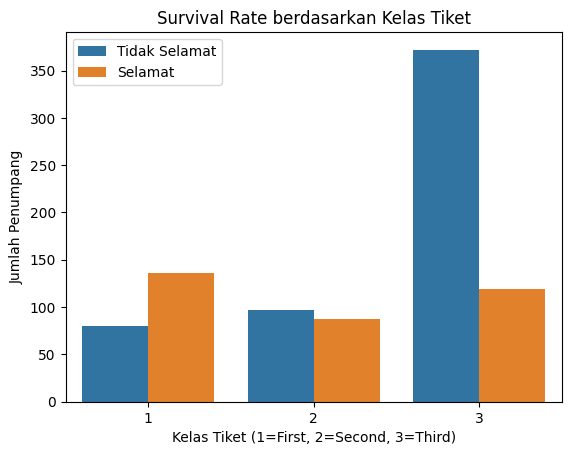

In [6]:
# Apakah kelas tiket mempengaruhi peluang selamat?
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Survival Rate berdasarkan Kelas Tiket')
plt.xlabel('Kelas Tiket (1=First, 2=Second, 3=Third)')
plt.ylabel('Jumlah Penumpang')
plt.legend(['Tidak Selamat', 'Selamat'])

plt.show()

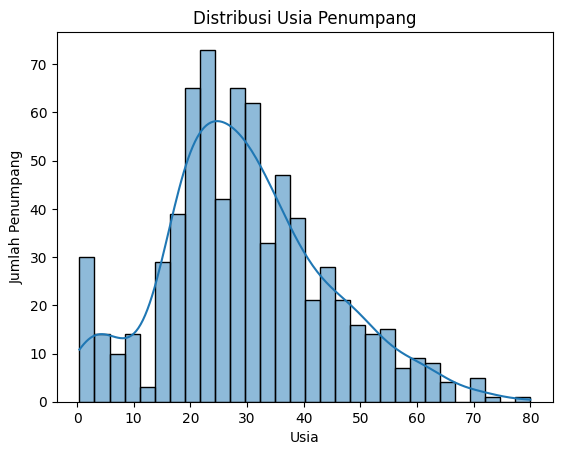

In [7]:
# Histogram untuk melihat distribusi usia penumpang
# bins=30 artinya data dibagi menjadi 30 kelompok
# kde=True menambahkan kurva distribusi di atas histogram
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
# dropna() mengabaikan baris yang usianya kosong (177 missing values)

plt.title('Distribusi Usia Penumpang')
plt.xlabel('Usia')
plt.ylabel('Jumlah Penumpang')

plt.show()

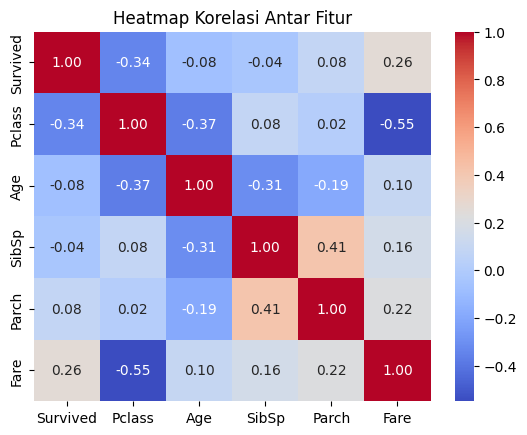

In [8]:
# Heatmap menunjukkan seberapa kuat hubungan antar kolom numerik
# Nilai mendekati 1 atau -1 = korelasi kuat
# Nilai mendekati 0 = tidak ada korelasi
correlation = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

sns.heatmap(
    correlation,
    annot=True,      # tampilkan angka korelasi di dalam kotak
    fmt='.2f',       # format 2 desimal
    cmap='coolwarm'  # warna merah = korelasi positif, biru = negatif
)

plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

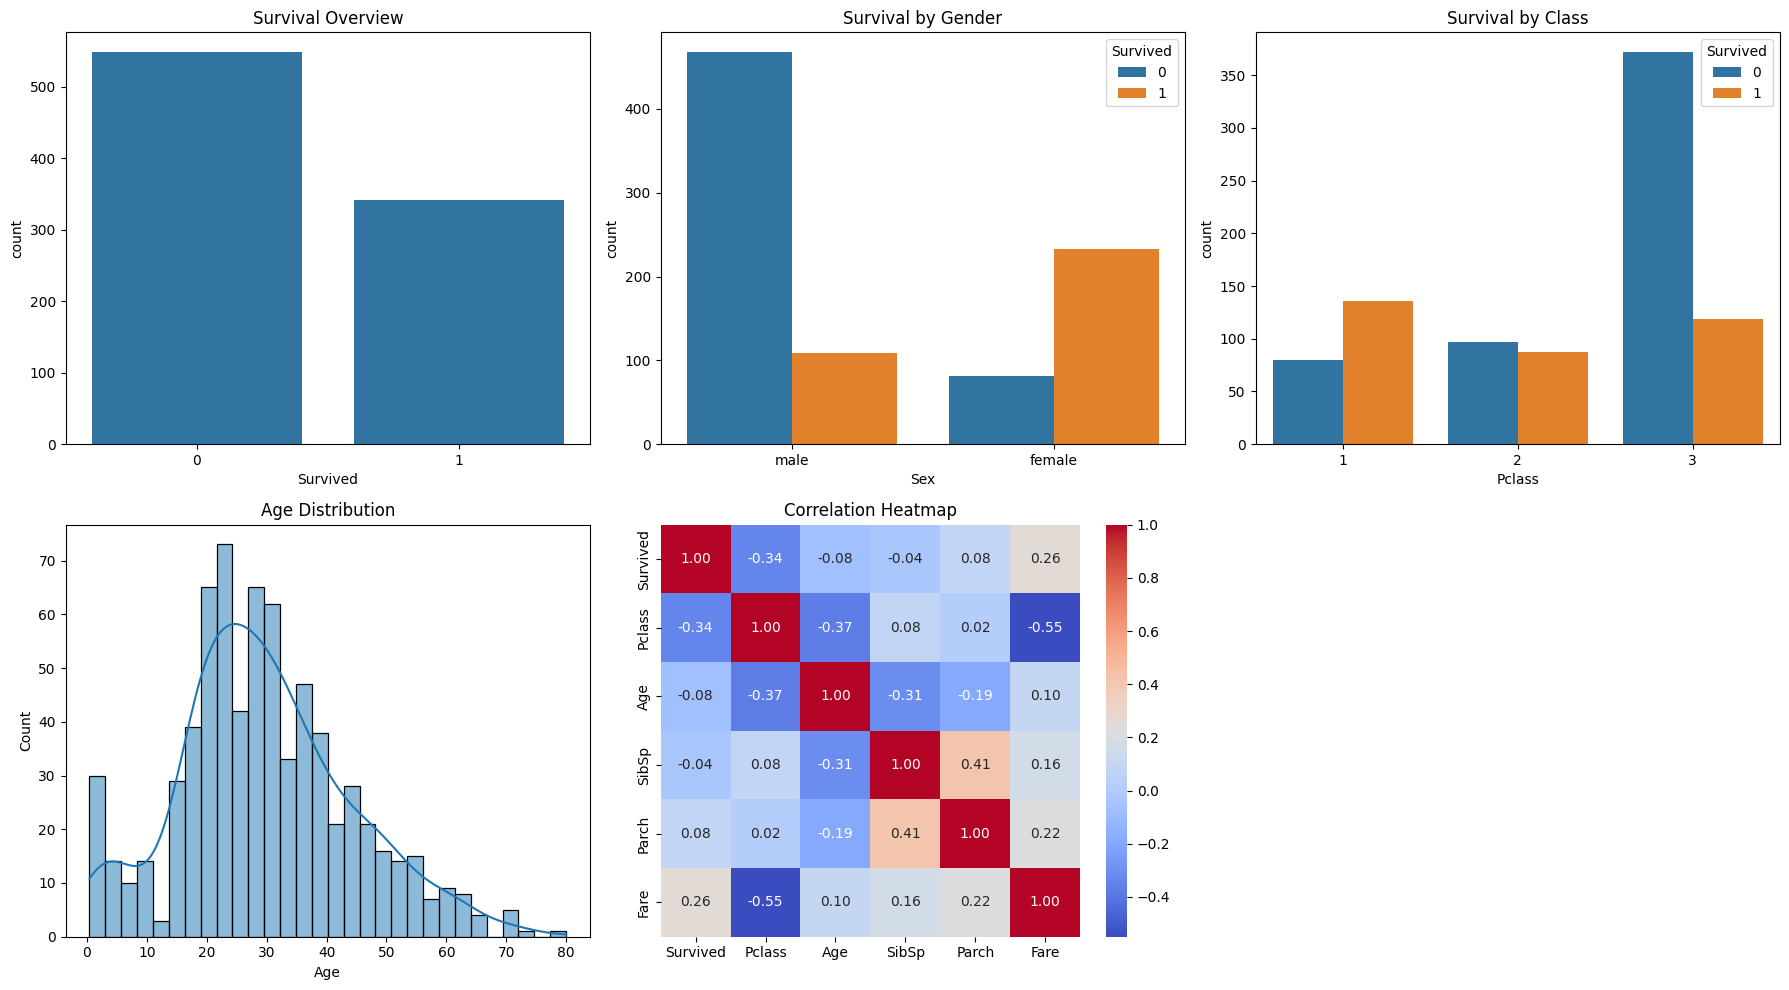

Grafik berhasil disimpan ke outputs/


In [9]:
# Simpan 5 grafik ke folder outputs

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# subplots membuat grid 2 baris x 3 kolom

# Grafik 1 — Survival count
sns.countplot(x='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Survival Overview')

# Grafik 2 — Survival by gender
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

# Grafik 3 — Survival by class
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0,2])
axes[0,2].set_title('Survival by Class')

# Grafik 4 — Age distribution
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Age Distribution')

# Grafik 5 — Heatmap korelasi
correlation = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

# Kosongkan slot terakhir yang tidak terpakai
axes[1,2].axis('off')

# Rapikan layout
plt.tight_layout()

# Simpan ke folder outputs
plt.savefig('../outputs/eda-charts.png', dpi=150)
plt.show()

print("Grafik berhasil disimpan ke outputs/")